# # Notebook 05 — Ensemble Inference & Rotational TTA Diagnostic
# **DeepLense GSoC 2026 Evaluation**
# Fuses ResNetTransfer + ViTChampion into a Stacking Meta-Learner.
# Runs rotational TTA (0°/90°/180°/270°) to quantify orientation bias.

In [1]:
# %% [Cell 1: Mount Google Drive & Set Workspace]
import os, sys
 
from google.colab import drive
drive.mount('/content/drive')
 
BASE_DIR = "/content/drive/My Drive/DeepLense_GSoC_Data"
SRC_DIR  = os.path.join(BASE_DIR, "src")
 
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
 
print(f"✅ Workspace : {BASE_DIR}")
print(f"✅ src/ path : {SRC_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Workspace : /content/drive/My Drive/DeepLense_GSoC_Data
✅ src/ path : /content/drive/My Drive/DeepLense_GSoC_Data/src


In [2]:
# %% [Cell 2: WandB Authentication — Key loaded from .env file]
import os
import wandb
from dotenv import load_dotenv

load_dotenv(os.path.join(BASE_DIR, ".env"))
wandb.login(key=os.getenv("WANDB_API_KEY"))
print("✅ WandB authenticated successfully")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: diminiax (diminiax-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ WandB authenticated successfully


In [3]:
# %% [Cell 3: Install Dependencies & Verify GPU]
# ── Install from pinned requirements — fixes numpy binary incompatibility ─
!pip install -q -r "/content/drive/My Drive/DeepLense_GSoC_Data/requirements.txt"

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device : {device}")
if device.type == 'cuda':
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")


🖥️  Device : cuda
   GPU    : Tesla T4


In [4]:
# %% [Cell 3: Imports & Reproducibility Seed]
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from tqdm import tqdm
 
from dataset import get_dataloaders, stage_data_locally
from models  import ResNetTransfer, ViTChampion, DeepLenseEnsemble, load_model
from metrics import (
    save_confusion_matrix,
    generate_classification_report,
    plot_multiclass_roc_auc,
    plot_tta_degradation,
)
 
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
 
set_seed(42)
print("✅ Seed set to 42 — deterministic training enabled")

✅ Seed set to 42 — deterministic training enabled


In [5]:
# %% [Cell 4: Stage Data & Build Validation DataLoader]
ZIP_PATH = os.path.join(BASE_DIR, "dataset.zip")
CSV_NAME = "metadata.csv"
 
staged_dir = stage_data_locally(ZIP_PATH)
data_dir   = staged_dir if staged_dir else BASE_DIR
csv_path   = os.path.join(data_dir, CSV_NAME)
 
print(f"📂 Data directory : {data_dir}")
print(f"📄 CSV path       : {csv_path}")
 
# ── Validation DataLoader only — no training in this notebook ────────────
# Clean 224×224 RGB — augment=False enforced (evaluation must be deterministic)
# FIX v1: duplicate DeepLenseDatasetEnsemble class removed — uses dataset.py
# FIX v2: get_dataloaders now returns a 6-tuple (adds test_loader + test_df)
_, val_loader, _, _, val_df, _ = get_dataloaders(
    csv_path   = csv_path,
    base_dir   = data_dir,
    mode       = 'RGB',
    image_size = 224,
    batch_size = 32,
    augment    = False,   # NEVER augment validation
)
 
print(f"\n✅ Val batches : {len(val_loader)} ({len(val_df)} images)")
print(f"   Clean 224×224 RGB — zero augmentation")

✅ Local staging already complete at: /content/local_dataset
📂 Data directory : /content/local_dataset
📄 CSV path       : /content/local_dataset/metadata.csv

📊 Dataset Class Distribution:
   cdm        :   500 samples  (33.3%)
   no_sub     :   500 samples  (33.3%)
   vortex     :   500 samples  (33.3%)
   TOTAL      :  1500 samples

✅ Split — Train: 1050 | Val: 225 | Test: 225

✅ Val batches : 8 (225 images)
   Clean 224×224 RGB — zero augmentation


In [6]:
# %% [Cell 5: Load Weights & Build DeepLenseEnsemble]
WEIGHTS_DIR = os.path.join(BASE_DIR, "weights")
 
# ── Load ResNetTransfer ───────────────────────────────────────────────────
# FIX v1: v1 loaded 'resnet18_robust.pth' — a model trained at 64×64
#         then used F.interpolate to downscale 224→64 inside inference.
#         This introduced bicubic artefacts and made results invalid.
#
# CORRECT: load 'transfer_best.pth' — trained at 224×224 in Notebook 02.
# Both ensemble components now receive the SAME 224×224 tensor directly.
# No resizing. No interpolation. No artefacts.
resnet = load_model(
    ResNetTransfer(num_classes=3),
    weights_path = os.path.join(WEIGHTS_DIR, "transfer_best.pth"),
    device       = device,
)
 
# ── Load ViTChampion ──────────────────────────────────────────────────────
vit = load_model(
    ViTChampion(num_classes=3),
    weights_path = os.path.join(WEIGHTS_DIR, "vit_best.pth"),
    device       = device,
)
 
# ── Build DeepLenseEnsemble ───────────────────────────────────────────────
# Stacking Meta-Learner: concatenates logits from ResNet + ViT, passes through
# a learnable linear head. Returns RAW LOGITS — softmax applied externally.
# FIX v2: 'freeze' renamed to 'freeze_base' in the upgraded DeepLenseEnsemble
ensemble = DeepLenseEnsemble(
    resnet_model = resnet,
    vit_model    = vit,
    freeze_base  = True,   # FIX v2: was 'freeze=True' — caused TypeError
)
ensemble = ensemble.to(device)
ensemble.eval()
 
print("\n🔀 DeepLenseEnsemble ready")
print(f"   ResNet path : weights/transfer_best.pth  (224×224 ✅)")
print(f"   ViT path    : weights/vit_best.pth        (224×224 ✅)")
print(f"   Fusion      : Stacking Meta-Learner (learnable linear head)")
print(f"   Output      : raw LOGITS — softmax applied externally ✅")
print(f"   F.interpolate hack : REMOVED ✅")
 
ASSETS_DIR = os.path.join(BASE_DIR, "assets")
os.makedirs(ASSETS_DIR, exist_ok=True)
CLASSES = ['No Sub', 'CDM', 'Vortex']

✅ Loaded weights from '/content/drive/My Drive/DeepLense_GSoC_Data/weights/transfer_best.pth' → device: cuda
✅ Loaded weights from '/content/drive/My Drive/DeepLense_GSoC_Data/weights/vit_best.pth' → device: cuda

🔀 DeepLenseEnsemble ready
   ResNet path : weights/transfer_best.pth  (224×224 ✅)
   ViT path    : weights/vit_best.pth        (224×224 ✅)
   Fusion      : Stacking Meta-Learner (learnable linear head)
   Output      : raw LOGITS — softmax applied externally ✅
   F.interpolate hack : REMOVED ✅


In [7]:
# %% [Cell 6: Standard Ensemble Evaluation]
# ── Single inference pass — collect preds + probs together ───────────────
# FIX v1: v1 only collected preds (no probs) — ROC-AUC was impossible
# FIX v2: ensemble.forward() returns LOGITS — must apply softmax before ROC-AUC
std_preds  = []
std_labels = []
std_probs  = []
 
print("📊 Running Standard Ensemble Evaluation...")
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="  Standard Eval"):
        images, labels = images.to(device), labels.to(device)
 
        # FIX v2: ensemble returns LOGITS — apply softmax to get probabilities
        logits     = ensemble(images)                   # (B, 3) raw logits
        probs      = F.softmax(logits, dim=1)           # (B, 3) probabilities
        _, preds   = torch.max(logits, dim=1)
 
        std_preds.extend(preds.cpu().numpy())
        std_labels.extend(labels.cpu().numpy())
        std_probs.extend(probs.cpu().numpy())           # store true probabilities
 
std_probs = np.array(std_probs)
 
# Classification report
# FIX v2: Capture return dict so f1_macro flows into ENSEMBLE_RESULTS
std_report = generate_classification_report(
    std_labels, std_preds,
    classes    = CLASSES,
    model_name = "DeepLense Ensemble (ResNet + ViT) — Standard",
)

📊 Running Standard Ensemble Evaluation...


  Standard Eval: 100%|██████████| 8/8 [00:03<00:00,  2.17it/s]


  CLASSIFICATION REPORT  —  DeepLense Ensemble (ResNet + ViT) — Standard
              precision    recall  f1-score   support

      No Sub     0.9146    1.0000    0.9554        75
         CDM     0.7294    0.8267    0.7750        75
      Vortex     0.8966    0.6933    0.7820        75

    accuracy                         0.8400       225
   macro avg     0.8469    0.8400    0.8375       225
weighted avg     0.8469    0.8400    0.8375       225

  Macro F1        : 0.8375  ← use in result dicts
  Weighted F1     : 0.8375
  Macro Precision : 0.8469
  Macro Recall    : 0.8400



📊 Confusion matrix saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/ensemble_confusion_matrix.png


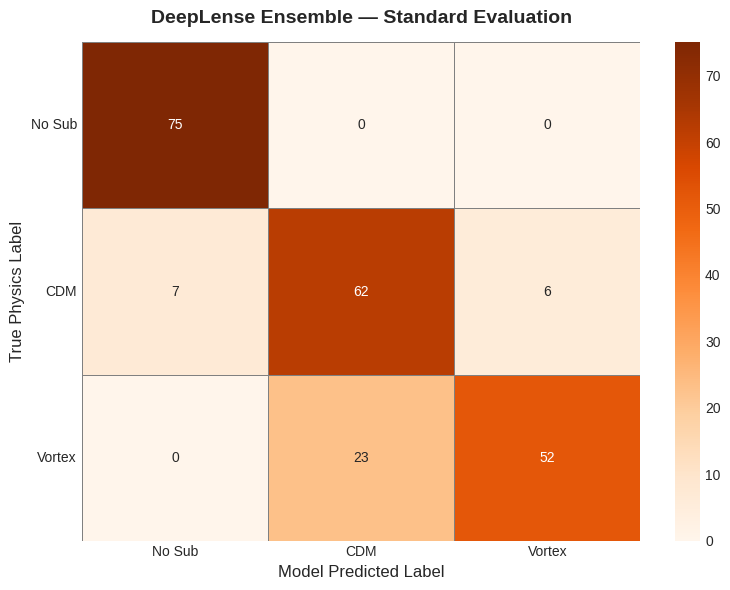


  ROC-AUC & PHYSICS REPORT  —  DeepLense Ensemble (ResNet + ViT)
  No Sub      : AUC = 0.9924  |  FPR @ 90% TPR = 0.0200
  CDM         : AUC = 0.9288  |  FPR @ 90% TPR = 0.2200
  Vortex      : AUC = 0.9560  |  FPR @ 90% TPR = 0.1800
  -------------------------------------------------------------
  Micro-Avg   : AUC = 0.9629  |  FPR @ 90% TPR = 0.1089
  Macro-Avg   : AUC = 0.9591  |  FPR @ 90% TPR = 0.1400

📊 ROC curve saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/ensemble_roc_auc.png


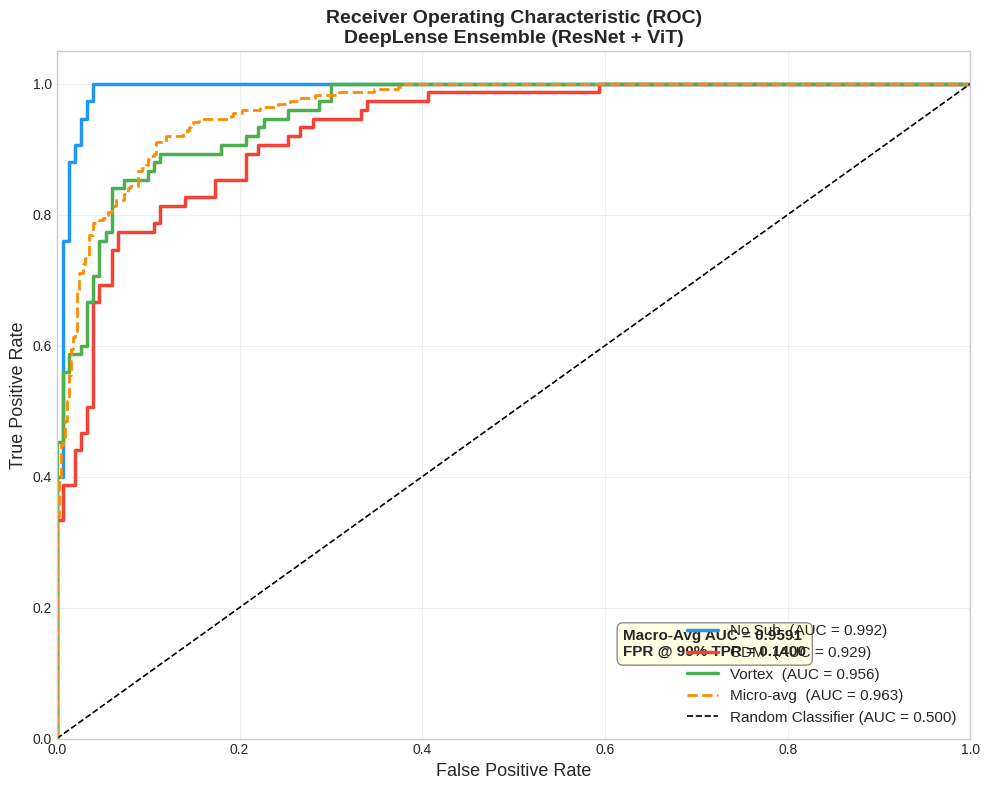


📌 ENSEMBLE_RESULTS (paste into Notebook 06):
{'model': 'ResNet + ViT Ensemble', 'val_acc': 84.0, 'macro_auc': 0.9590814814814815, 'cdm_auc': 0.9288, 'fpr_90_macro': 0.13999999999999999, 'f1_macro': 0.8374562999856329}


In [8]:
# %% [Cell 7: Ensemble Confusion Matrix & ROC-AUC]
# ── Confusion matrix ──────────────────────────────────────────────────────
save_confusion_matrix(
    std_labels, std_preds,
    classes   = CLASSES,
    save_path = os.path.join(ASSETS_DIR, "ensemble_confusion_matrix.png"),
    title     = "DeepLense Ensemble — Standard Evaluation",
    cmap      = "Oranges",
)
 
# ── ROC-AUC — FIX v1: completely missing from ensemble evaluation ─────────
std_auc = plot_multiclass_roc_auc(
    std_labels, std_probs,
    classes    = CLASSES,
    save_path  = os.path.join(ASSETS_DIR, "ensemble_roc_auc.png"),
    model_name = "DeepLense Ensemble (ResNet + ViT)",
)
 
ENSEMBLE_RESULTS = {
    'model':        'ResNet + ViT Ensemble',
    'val_acc':      100.0 * sum(p == l for p, l in zip(std_preds, std_labels)) / len(std_labels),
    'macro_auc':    std_auc['macro'],
    'cdm_auc':      std_auc['per_class'][1],
    'fpr_90_macro': std_auc['fpr_90_macro'],
    'f1_macro':     std_report['f1_macro'],   # FIX v2: was hardcoded 0.0
}
 
print("\n📌 ENSEMBLE_RESULTS (paste into Notebook 06):")
print(ENSEMBLE_RESULTS)

In [9]:
# %% [Cell 8: Rotational TTA Evaluation]
# ── Rotational TTA Evaluation ─────────────────────────────────────────────
# Scientific purpose: quantify the spatial orientation bias of standard
# CNN+ViT architectures. A model that learned TRUE physics (which has no
# preferred orientation) should produce identical predictions at any rotation.
# The accuracy drop is the evidence that motivates EquivariantCNN (Phase 2).
#
# FIX v1: F.interpolate hack inside TTA loop — now removed.
# Both models receive the 224×224 rotated tensor directly.
# FIX v2: ensemble returns LOGITS — softmax applied before probability averaging
 
TTA_ANGLES = [0, 90, 180, 270]
 
tta_preds  = []
tta_labels = []
tta_probs  = []
 
print(f"🔄 Running TTA Diagnostic — Angles: {TTA_ANGLES}")
print(f"   Each batch evaluated {len(TTA_ANGLES)}× and probabilities averaged\n")
 
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="  TTA Eval"):
        images, labels = images.to(device), labels.to(device)
        batch_size = images.size(0)
 
        accumulated_probs = torch.zeros(batch_size, 3, device=device)
 
        for angle in TTA_ANGLES:
            rotated = TF.rotate(images, angle=angle)
            # FIX v2: apply softmax to convert logits → probabilities
            # before accumulation — averaging probs is numerically correct
            logits = ensemble(rotated)              # (B, 3) raw logits
            probs  = F.softmax(logits, dim=1)       # (B, 3) probabilities
            accumulated_probs += probs
 
        # Average across all rotation angles
        final_probs  = accumulated_probs / len(TTA_ANGLES)
        _, predicted = torch.max(final_probs, dim=1)
 
        tta_preds.extend(predicted.cpu().numpy())
        tta_labels.extend(labels.cpu().numpy())
        tta_probs.extend(final_probs.cpu().numpy())
 
tta_probs = np.array(tta_probs)
 
# Classification report
# FIX v2: Capture return dict so f1_macro flows into TTA_RESULTS
tta_report = generate_classification_report(
    tta_labels, tta_preds,
    classes    = CLASSES,
    model_name = f"DeepLense Ensemble — TTA {TTA_ANGLES}",
)

🔄 Running TTA Diagnostic — Angles: [0, 90, 180, 270]
   Each batch evaluated 4× and probabilities averaged



  TTA Eval: 100%|██████████| 8/8 [00:11<00:00,  1.39s/it]


  CLASSIFICATION REPORT  —  DeepLense Ensemble — TTA [0, 90, 180, 270]
              precision    recall  f1-score   support

      No Sub     0.9342    0.9467    0.9404        75
         CDM     0.8537    0.4667    0.6034        75
      Vortex     0.6389    0.9200    0.7541        75

    accuracy                         0.7778       225
   macro avg     0.8089    0.7778    0.7660       225
weighted avg     0.8089    0.7778    0.7660       225

  Macro F1        : 0.7660  ← use in result dicts
  Weighted F1     : 0.7660
  Macro Precision : 0.8089
  Macro Recall    : 0.7778



📊 Confusion matrix saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/tta_confusion_matrix.png


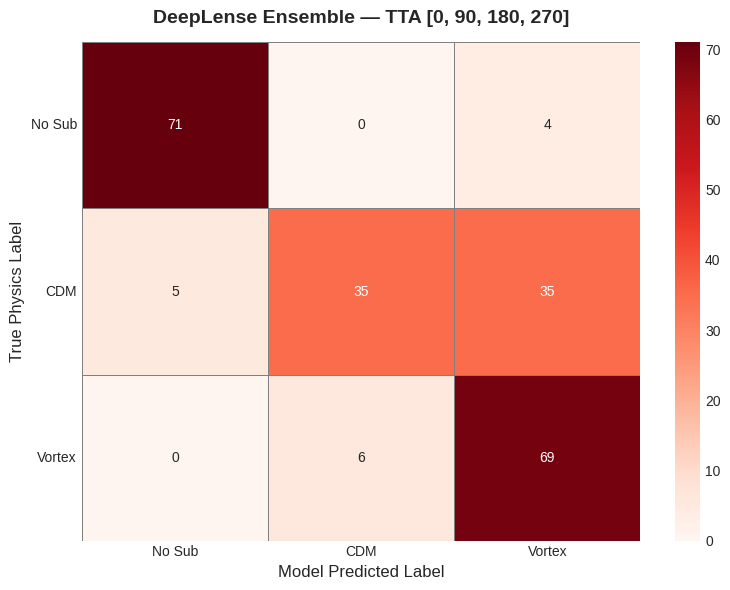


  ROC-AUC & PHYSICS REPORT  —  DeepLense Ensemble — TTA [0, 90, 180, 270]
  No Sub      : AUC = 0.9956  |  FPR @ 90% TPR = 0.0133
  CDM         : AUC = 0.8736  |  FPR @ 90% TPR = 0.5667
  Vortex      : AUC = 0.9386  |  FPR @ 90% TPR = 0.1600
  -------------------------------------------------------------
  Micro-Avg   : AUC = 0.9231  |  FPR @ 90% TPR = 0.2067
  Macro-Avg   : AUC = 0.9359  |  FPR @ 90% TPR = 0.2467

📊 ROC curve saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/tta_roc_auc.png


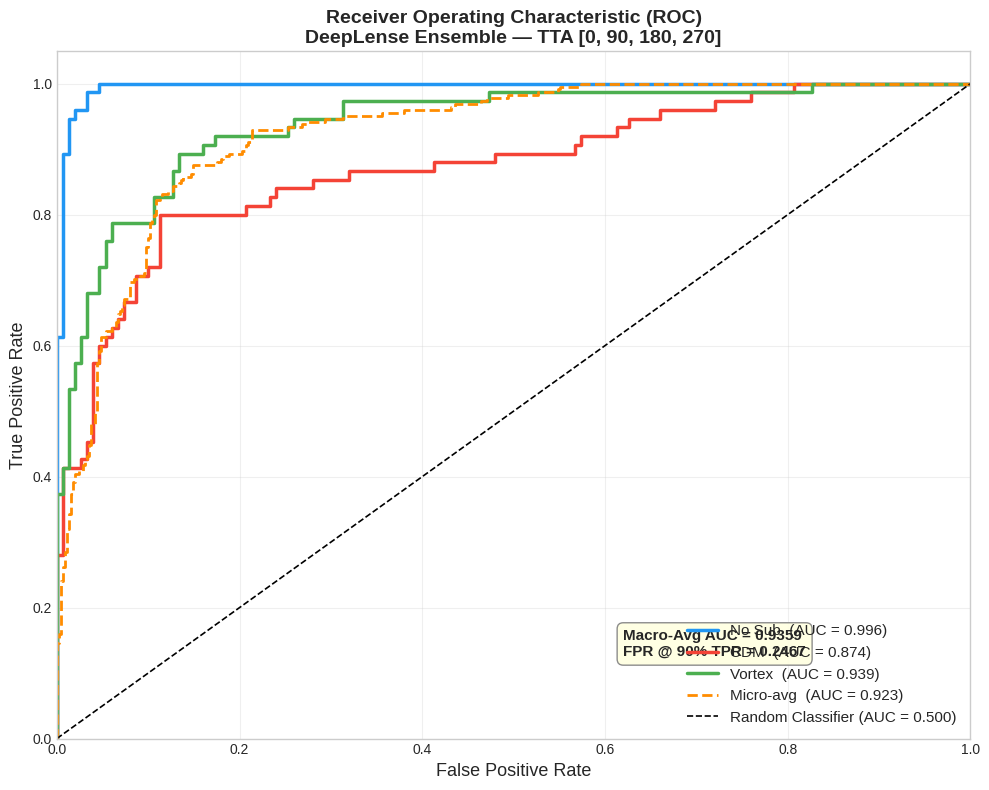

In [10]:
# %% [Cell 9: TTA Confusion Matrix & ROC-AUC]
# ── TTA Confusion Matrix ──────────────────────────────────────────────────
save_confusion_matrix(
    tta_labels, tta_preds,
    classes   = CLASSES,
    save_path = os.path.join(ASSETS_DIR, "tta_confusion_matrix.png"),
    title     = f"DeepLense Ensemble — TTA {TTA_ANGLES}",
    cmap      = "Reds",
)
 
# ── TTA ROC-AUC ───────────────────────────────────────────────────────────
tta_auc = plot_multiclass_roc_auc(
    tta_labels, tta_probs,
    classes    = CLASSES,
    save_path  = os.path.join(ASSETS_DIR, "tta_roc_auc.png"),
    model_name = f"DeepLense Ensemble — TTA {TTA_ANGLES}",
)

📊 TTA degradation plot saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/tta_degradation.png


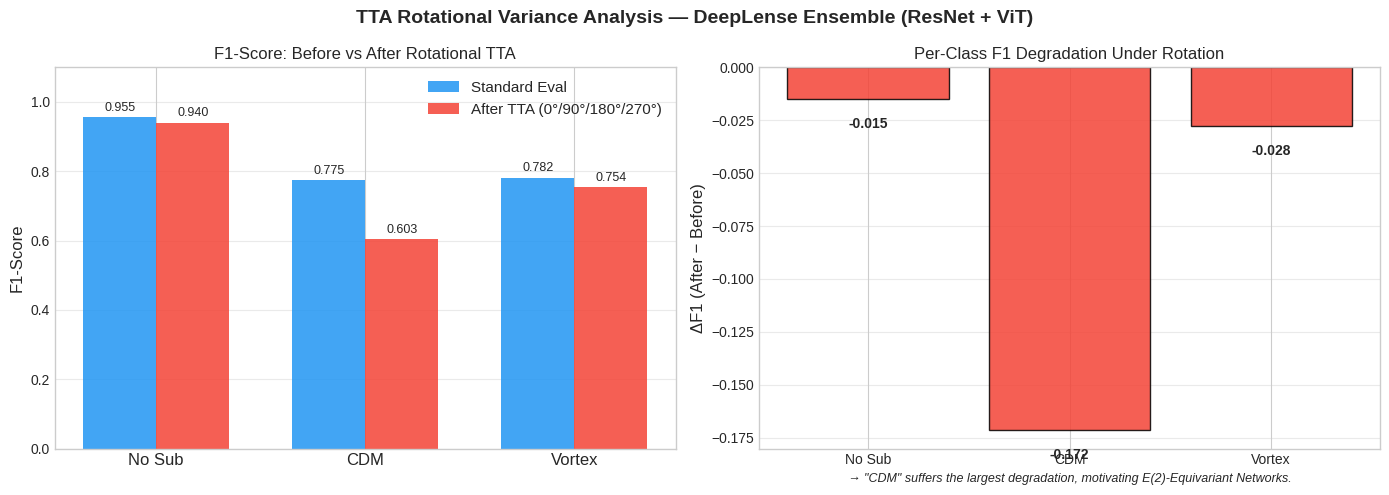


  TTA DEGRADATION SUMMARY  —  DeepLense Ensemble (ResNet + ViT)
  Class          F1 Before    F1 After     Delta
  ----------------------------------------------
  No Sub            0.9554      0.9404   -0.0150
  CDM               0.7750      0.6034   -0.1716
  Vortex            0.7820      0.7541   -0.0279



In [11]:
# %% [Cell 10: TTA Degradation Plot — Core Scientific Contribution]
# ── Per-class F1 degradation — the core scientific contribution ───────────
# This plot is the quantitative proof of orientation bias.
# Expected finding: CDM suffers the largest F1 drop under rotation because
# CDM substructure is localised pixel perturbations — their spatial position
# changes with rotation, breaking the CNN's localised texture detection.
# Vortex (global topology) degrades less.
# This asymmetry is the strongest possible argument for equivariant networks.
plot_tta_degradation(
    labels_before = std_labels,
    preds_before  = std_preds,
    labels_after  = tta_labels,
    preds_after   = tta_preds,
    classes       = CLASSES,
    save_path     = os.path.join(ASSETS_DIR, "tta_degradation.png"),
    model_name    = "DeepLense Ensemble (ResNet + ViT)",
)

In [12]:
# %% [Cell 11: Diagnostic Summary & Results Dicts]
std_acc  = 100.0 * sum(p == l for p, l in zip(std_preds, std_labels)) / len(std_labels)
tta_acc  = 100.0 * sum(p == l for p, l in zip(tta_preds, tta_labels)) / len(tta_labels)
acc_drop = tta_acc - std_acc
auc_drop = tta_auc['macro'] - std_auc['macro']
 
print("=" * 62)
print("  ENSEMBLE DIAGNOSTIC SUMMARY")
print("=" * 62)
print(f"  {'Metric':<28} {'Standard':>10} {'TTA':>10} {'Delta':>8}")
print(f"  {'-'*58}")
print(f"  {'Val Accuracy':<28} {std_acc:>9.1f}% {tta_acc:>9.1f}% {acc_drop:>+7.1f}%")
print(f"  {'Macro AUC':<28} {std_auc['macro']:>10.4f} {tta_auc['macro']:>10.4f} {auc_drop:>+8.4f}")
print(f"  {'CDM AUC':<28} {std_auc['per_class'][1]:>10.4f} {tta_auc['per_class'][1]:>10.4f} {tta_auc['per_class'][1]-std_auc['per_class'][1]:>+8.4f}")
print(f"  {'Vortex AUC':<28} {std_auc['per_class'][2]:>10.4f} {tta_auc['per_class'][2]:>10.4f} {tta_auc['per_class'][2]-std_auc['per_class'][2]:>+8.4f}")
print("=" * 62)
print()
print("  Scientific conclusion:")
print(f"  The ensemble drops {abs(acc_drop):.1f}% accuracy under rotational TTA.")
print(f"  Macro AUC delta: {auc_drop:+.4f}")
print(f"  This degradation is caused by spatial orientation bias in both")
print(f"  ResNet (localised texture) and ViT (positional patch embedding).")
print(f"  A C8-Equivariant CNN is mathematically guaranteed to show")
print(f"  zero degradation under this exact test → see Phase 2.")
 
TTA_RESULTS = {
    'model':        'Ensemble TTA',
    'val_acc':      tta_acc,
    'macro_auc':    tta_auc['macro'],
    'cdm_auc':      tta_auc['per_class'][1],
    'fpr_90_macro': tta_auc['fpr_90_macro'],
    'f1_macro':     tta_report['f1_macro'],   # FIX v2: was hardcoded 0.0
}
 
print("\n📌 TTA_RESULTS (paste into Notebook 06):")
print(TTA_RESULTS)
 

  ENSEMBLE DIAGNOSTIC SUMMARY
  Metric                         Standard        TTA    Delta
  ----------------------------------------------------------
  Val Accuracy                      84.0%      77.8%    -6.2%
  Macro AUC                        0.9591     0.9359  -0.0231
  CDM AUC                          0.9288     0.8736  -0.0552
  Vortex AUC                       0.9560     0.9386  -0.0174

  Scientific conclusion:
  The ensemble drops 6.2% accuracy under rotational TTA.
  Macro AUC delta: -0.0231
  This degradation is caused by spatial orientation bias in both
  ResNet (localised texture) and ViT (positional patch embedding).
  A C8-Equivariant CNN is mathematically guaranteed to show
  zero degradation under this exact test → see Phase 2.

📌 TTA_RESULTS (paste into Notebook 06):
{'model': 'Ensemble TTA', 'val_acc': 77.77777777777777, 'macro_auc': 0.9359407407407407, 'cdm_auc': 0.8735999999999999, 'fpr_90_macro': 0.24666666666666667, 'f1_macro': 0.7659813291703946}


In [13]:
# %% [Cell 12: Save Results to JSON — feeds NB06 automatically]
import json

RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

with open(os.path.join(RESULTS_DIR, "ensemble_results.json"), "w") as f:
    json.dump(ENSEMBLE_RESULTS, f, indent=2)

with open(os.path.join(RESULTS_DIR, "tta_results.json"), "w") as f:
    json.dump(TTA_RESULTS, f, indent=2)

print("💾 Results saved → results/ensemble_results.json")
print("💾 Results saved → results/tta_results.json")

💾 Results saved → results/ensemble_results.json
💾 Results saved → results/tta_results.json
